In [1]:
import pandas as pd
df = pd.read_csv('feature_eng_df_final.csv')

In [2]:
df.head()

,age,education,monthly_salary,years_of_employment,company_type,house_type,monthly_rent,family_size,dependents,school_fees,...,affordability_ratio,credit_score_category,credit_score_numeric,combined_credit_risk,employment_tenure_category,is_long_term_employed,income_per_family_member,savings_to_income_ratio,credit_stability_score,loan_affordability_index
0,38.0,3.0,11.321777,0.641854,2.0,0.0,1.280128,3,2,0.0,...,-2.443993,Fair,2,3,Entry-level,0,3.773926,0.042580,423.623565,1.205905
1,38.0,1.0,9.975855,2.079442,4.0,1.0,-0.814566,2,1,5100.0,...,-513.331366,Good,1,2,Mid-level,1,4.987927,-0.177067,1484.721261,1.178826
2,38.0,3.0,11.363276,1.916923,0.0,2.0,-0.814566,4,3,0.0,...,-1.321418,Fair,2,2,Mid-level,1,2.840819,0.346565,1245.999698,1.111593
3,58.0,0.0,11.109473,1.163151,2.0,2.0,-0.814566,5,4,11400.0,...,-1027.461671,Good,1,1,Entry-level,0,2.221895,0.200884,796.758305,1.136398
4,48.0,3.0,10.956073,1.481605,2.0,1.0,-0.814566,4,3,9400.0,...,-859.501890,Excellent,0,0,Mid-level,0,2.739018,-0.153537,1140.835497,1.135187


In [3]:
len(df.columns)

45

In [4]:
df.select_dtypes(include='object').columns

Index(['age_group', 'credit_score_category', 'employment_tenure_category'], dtype='object')

In [5]:
# dropping credit score category since it already encoded as new column credit_score_numeric
df.drop('credit_score_category',axis=1,inplace=True)

In [6]:
#let's encode the binned age group column derived from age column in to ordinal encoder
df['age_group'].unique()
age_group_order = ['25-34','35-44', '45-54', '55-64']
from sklearn.preprocessing import OrdinalEncoder
age_group_encoder = OrdinalEncoder(categories=[age_group_order])
df['age_group'] = age_group_encoder.fit_transform(df[['age_group']])
print("after encoding df['age_group']",df['age_group'].unique())
df.drop('age',axis=1,inplace=True)

after encoding df['age_group'] [1. 3. 2. 0.]


In [7]:
#let encode binned employment experience type from year_of_employment column 
df['employment_tenure_category'].unique()
employment_order = ['Entry-level', 'Mid-level', 'Experienced']
emp_category_encoder = OrdinalEncoder(categories=[employment_order])
df['employment_tenure_category'] = emp_category_encoder.fit_transform(df[['employment_tenure_category']])
print("after encoding emp tenure category ",df['employment_tenure_category'].unique())
df.drop('years_of_employment',axis=1,inplace=True)

after encoding emp tenure category  [0. 1. 2.]


In [8]:
from sklearn.model_selection import train_test_split
X=df.drop(['emi_eligibility'],axis=1)
y=df['emi_eligibility']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(322243, 41)
(80561, 41)
(322243,)
(80561,)


In [9]:
X_train.columns

Index(['education', 'monthly_salary', 'company_type', 'house_type',
       'monthly_rent', 'family_size', 'dependents', 'school_fees',
       'college_fees', 'travel_expenses', 'groceries_utilities',
       'other_monthly_expenses', 'existing_loans', 'current_emi_amount',
       'credit_score', 'bank_balance', 'emergency_fund', 'emi_scenario',
       'requested_amount', 'requested_tenure', 'max_monthly_emi', 'age_group',
       'gender_FEMALE', 'gender_MALE', 'marital_status_Married',
       'marital_status_Single', 'employment_type_Government',
       'employment_type_Private', 'employment_type_Self-employed',
       'debt_to_income_ratio', 'total_expenses', 'expense_to_income_ratio',
       'affordability_ratio', 'credit_score_numeric', 'combined_credit_risk',
       'employment_tenure_category', 'is_long_term_employed',
       'income_per_family_member', 'savings_to_income_ratio',
       'credit_stability_score', 'loan_affordability_index'],
      dtype='object')

In [99]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
X_const = add_constant(X_train)
vif_data = pd.DataFrame()
vif_data["Feature"] = X_const.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_const.values, i)
    for i in range(X_const.shape[1])
]

vif_data = vif_data.sort_values(by="VIF", ascending=False)
print(vif_data)


C:\Users\RAM\miniconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
C:\Users\RAM\miniconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


                          Feature           VIF
9                    college_fees           inf
5                    monthly_rent           inf
8                     school_fees           inf
24                    gender_MALE           inf
23                  gender_FEMALE           inf
25         marital_status_Married           inf
13                 existing_loans           inf
12         other_monthly_expenses           inf
11            groceries_utilities           inf
10                travel_expenses           inf
35           combined_credit_risk           inf
32        expense_to_income_ratio           inf
31                 total_expenses           inf
30           debt_to_income_ratio           inf
29  employment_type_Self-employed           inf
28        employment_type_Private           inf
27     employment_type_Government           inf
34           credit_score_numeric           inf
33            affordability_ratio           inf
26          marital_status_Single       

In [10]:
#Prdeciting Features
X_train.drop(['max_monthly_emi'],axis=1,inplace=True)
X_test.drop(['max_monthly_emi'],axis=1,inplace=True)

In [11]:
#dropping functional duplicates...
columns_to_drop = ['monthly_rent','school_fees','college_fees','travel_expenses','groceries_utilities','other_monthly_expenses']
X_train= X_train.drop(columns=columns_to_drop, axis=1)
X_test= X_test.drop(columns=columns_to_drop, axis=1)

In [12]:
print(len(X_train.columns))
X_train.columns

34


Index(['education', 'monthly_salary', 'company_type', 'house_type',
       'family_size', 'dependents', 'existing_loans', 'current_emi_amount',
       'credit_score', 'bank_balance', 'emergency_fund', 'emi_scenario',
       'requested_amount', 'requested_tenure', 'age_group', 'gender_FEMALE',
       'gender_MALE', 'marital_status_Married', 'marital_status_Single',
       'employment_type_Government', 'employment_type_Private',
       'employment_type_Self-employed', 'debt_to_income_ratio',
       'total_expenses', 'expense_to_income_ratio', 'affordability_ratio',
       'credit_score_numeric', 'combined_credit_risk',
       'employment_tenure_category', 'is_long_term_employed',
       'income_per_family_member', 'savings_to_income_ratio',
       'credit_stability_score', 'loan_affordability_index'],
      dtype='object')

**Scaling before traning the model**

Why scaling? it will have a positive impact on model performance in training.

## Scaling Numerical Features

Standard scaling is applied to normalize the range of independent variables or features of the data. This helps in improving the performance of machine learning algorithms, especially those that are sensitive to the scale of the input features (e.g., algorithms that use distance calculations).


age
monthly_salary
years_of_employment
monthly_rent
school_fees
college_fees
travel_expenses
groceries_utilities
other_monthly_expenses
current_emi_amount
credit_score
bank_balance
emergency_fund

In [13]:
print(X_train.columns)
print(len(X_train.columns))

Index(['education', 'monthly_salary', 'company_type', 'house_type',
       'family_size', 'dependents', 'existing_loans', 'current_emi_amount',
       'credit_score', 'bank_balance', 'emergency_fund', 'emi_scenario',
       'requested_amount', 'requested_tenure', 'age_group', 'gender_FEMALE',
       'gender_MALE', 'marital_status_Married', 'marital_status_Single',
       'employment_type_Government', 'employment_type_Private',
       'employment_type_Self-employed', 'debt_to_income_ratio',
       'total_expenses', 'expense_to_income_ratio', 'affordability_ratio',
       'credit_score_numeric', 'combined_credit_risk',
       'employment_tenure_category', 'is_long_term_employed',
       'income_per_family_member', 'savings_to_income_ratio',
       'credit_stability_score', 'loan_affordability_index'],
      dtype='object')
34


In [14]:
from sklearn.preprocessing import StandardScaler
standardscaler = StandardScaler()

In [15]:
columns_to_scale = ['monthly_salary','family_size','dependents','current_emi_amount',
       'credit_score', 'bank_balance', 'emergency_fund','requested_amount','requested_tenure','debt_to_income_ratio', 'total_expenses', 'expense_to_income_ratio',
       'affordability_ratio', 'credit_score_numeric', 'combined_credit_risk',
       'income_per_family_member', 'savings_to_income_ratio',
       'credit_stability_score', 'loan_affordability_index']
# Filter columns_to_scale to ensure they exist in the DataFrame
existing_columns_to_scale = [col for col in columns_to_scale if col in df.columns]

if existing_columns_to_scale:
    # Apply StandardScaler to the identified numerical columns
    X_train[existing_columns_to_scale] = standardscaler.fit_transform(X_train[existing_columns_to_scale])
    X_test[existing_columns_to_scale]  = standardscaler.fit_transform(X_test[existing_columns_to_scale])
    print("Scaled the following columns:", existing_columns_to_scale)
    #display(x[existing_columns_to_scale].head())
else:
    print("No existing columns found to scale from the provided list.")

Scaled the following columns: ['monthly_salary', 'family_size', 'dependents', 'current_emi_amount', 'credit_score', 'bank_balance', 'emergency_fund', 'requested_amount', 'requested_tenure', 'debt_to_income_ratio', 'total_expenses', 'expense_to_income_ratio', 'affordability_ratio', 'credit_score_numeric', 'combined_credit_risk', 'income_per_family_member', 'savings_to_income_ratio', 'credit_stability_score', 'loan_affordability_index']


**2 .Checking count of each categorical target variable in train data**

Reason: Checking for class imbalance


Outcome : can take a decision on whether sampling is needed or not


In [16]:
y_train.value_counts()

emi_eligibility
2.0    249061
0.0     59265
1.0     13917
Name: count, dtype: int64

In [17]:
# Set to None to display all columns
pd.set_option('display.max_columns', None)

# Set to None to display all rows (Warning: Don't do this with 80k rows!)
# pd.set_option('display.max_rows', None) 

# Now view your dataframe
X_train.head()

,education,monthly_salary,company_type,house_type,family_size,dependents,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,age_group,gender_FEMALE,gender_MALE,marital_status_Married,marital_status_Single,employment_type_Government,employment_type_Private,employment_type_Self-employed,debt_to_income_ratio,total_expenses,expense_to_income_ratio,affordability_ratio,credit_score_numeric,combined_credit_risk,employment_tenure_category,is_long_term_employed,income_per_family_member,savings_to_income_ratio,credit_stability_score,loan_affordability_index
357047,1.0,-1.008263,2.0,2.0,0.055467,0.055467,0,-0.812140,-0.018379,-1.375000,-1.763453,1,-0.938739,-0.668377,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,-0.813741,1.100935,1.204215,-1.203494,-0.091579,-0.437252,1.0,0,-0.430996,-1.707687,0.132483,-0.277967
386311,1.0,-1.624974,2.0,2.0,-0.874591,-0.874591,1,1.016671,0.874922,-0.278982,-0.227699,3,0.506372,0.932781,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.189316,-0.914252,-0.911310,0.910257,-1.260509,-0.437252,1.0,0,0.221956,-0.261634,0.064897,1.391276
106376,1.0,0.176422,4.0,1.0,0.055467,0.055467,0,-0.812140,-0.573309,0.127232,0.614802,0,-0.384195,-1.165288,2.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,-0.813741,1.180369,1.151771,-1.151049,1.077350,0.478537,0.0,0,-0.335408,0.413454,-0.841402,-0.439744
188259,0.0,-0.787404,0.0,0.0,-1.804649,-1.804649,0,-0.812140,0.414736,-0.902282,-0.958267,2,0.073015,-0.447528,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,-0.813741,-0.913793,-0.911058,0.911775,-0.091579,-0.437252,1.0,1,2.532832,-0.988357,0.730420,0.478258
355920,1.0,0.342040,2.0,1.0,-1.804649,-1.804649,1,1.215206,1.362177,-0.426652,-0.982005,0,-0.256959,-0.613165,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.181454,-0.913841,-0.911404,0.910358,-1.260509,-0.437252,0.0,0,2.806224,-0.696688,-1.209464,-0.420175


In [18]:
import mlflow
import mlflow.sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,roc_auc_score,classification_report,confusion_matrix,roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
# Set a tracking URI for MLflow. By default, it uses a local folder 'mlruns'.
# You can also set it to a database or a remote server.
# mlflow.set_tracking_uri("sqlite:///mlruns.db") # Example for a database

print(f"MLflow Version: {mlflow.__version__}")

MLflow Version: 3.9.0


### Example: Tracking a Logistic Regression Model

Let's assume you have your `X_train`, `X_test`, `y_train`, `y_test` data ready from previous steps. Train with cv in Logistic Regression model.

In [19]:
from sklearn.model_selection import GridSearchCV
log_reg_mod = LogisticRegression(random_state=42, solver='lbfgs') 

param_grid = {
    "max_iter": [1000, 2000],
    "class_weight": ['balanced', None], # See if 'balanced' actually helps vs the default
    "penalty": ['l2'],
    "C": [0.01, 0.1, 1, 10]            #This controls regularization strength
}

grid = GridSearchCV(
    estimator=log_reg_mod,
    param_grid=param_grid,
    cv=5,                              # 5-fold is more standard than 3
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1                          # Shows progress so you know it's working
)

grid.fit(X_train, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


,estimator,LogisticRegre...ndom_state=42)
,param_grid,"{'C': [0.01, 0.1, ...], 'class_weight': ['balanced', None], 'max_iter': [1000, 2000], 'penalty': ['l2']}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [20]:
log_reg_model = grid.best_estimator_

In [30]:
print(grid.best_params_)

{'C': 10, 'class_weight': 'balanced', 'max_iter': 1000, 'penalty': 'l2'}


In [21]:
# Make predictions
y_pred = log_reg_model.predict(X_test)
y_pred_prob = log_reg_model.predict_proba(X_test)
# view metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')
roc_auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovo', average='macro')
print("accuracy --",accuracy)
print("precision---",precision)
print("recall score---",recall)
print("f1 score.----",f1)
print("roc_auc--",roc_auc)

accuracy -- 0.7649731259542458
precision--- 0.6285587934897509
recall score--- 0.7288241570497993
f1 score.---- 0.6126556417533874
roc_auc-- 0.8810752950072965


In [22]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

         0.0       0.76      0.71      0.73     14817
         1.0       0.14      0.70      0.23      3479
         2.0       0.99      0.78      0.87     62265

    accuracy                           0.76     80561
   macro avg       0.63      0.73      0.61     80561
weighted avg       0.91      0.76      0.82     80561



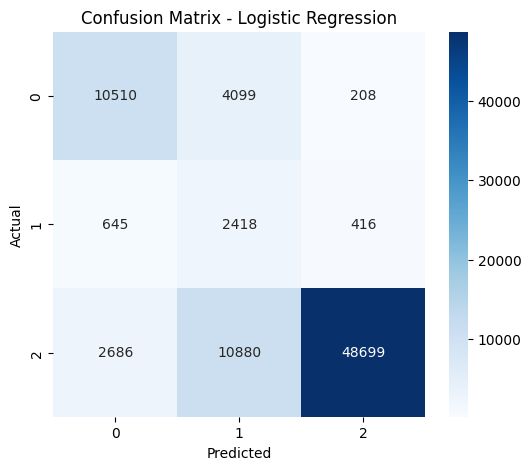

In [23]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

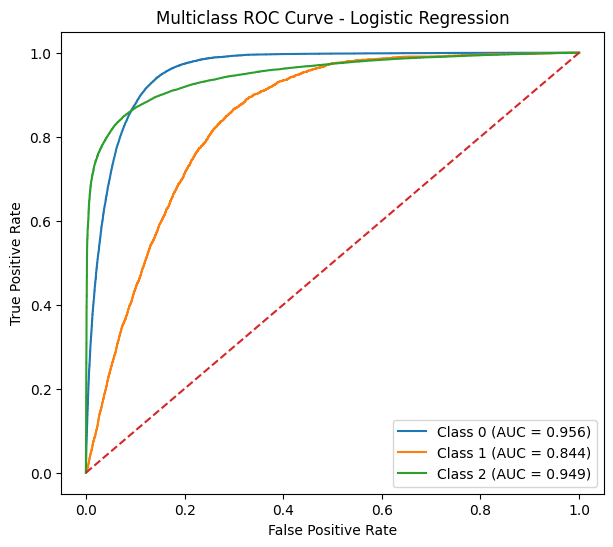

In [24]:
from sklearn.preprocessing import label_binarize
y_test_bin = label_binarize(y_test, classes=[0,1,2])

plt.figure(figsize=(7,6))

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc = roc_auc_score(y_test_bin[:, i], y_pred_prob[:, i])
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve - Logistic Regression")
plt.legend()
plt.show()

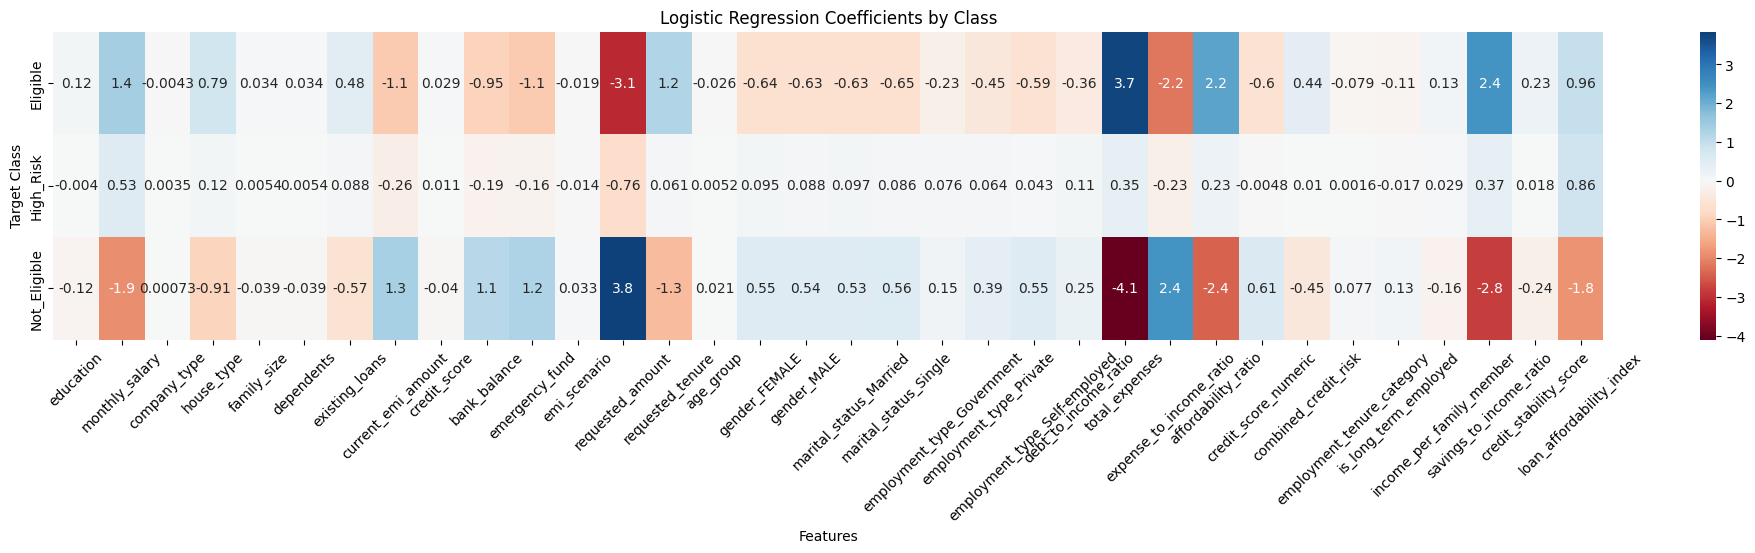

In [25]:
coef_df = pd.DataFrame(
        log_reg_model.coef_,
        columns=X_train.columns,
        index=["Eligible", "High_Risk", "Not_Eligible"]
    )
plt.figure(figsize=(25,4))

# Use a diverging color map (RdBu) so 0 is neutral, 
# Blue is positive correlation, Red is negative.
sns.heatmap(coef_df, annot=True, cmap='RdBu', center=0)

plt.title("Logistic Regression Coefficients by Class")
plt.xlabel("Features")
plt.ylabel("Target Class")
plt.xticks(rotation=45)
plt.show()

In [31]:
import mlflow

run_id = "0ea6dcac193140c0a9ee090d9349c12a"

with mlflow.start_run(run_id=run_id):
    # Log those missing params here
    
    print("Successfully updated run: kindly-sloth-787")

Successfully updated run: kindly-sloth-787
🏃 View run kindly-sloth-787 at: http://127.0.0.1:5000/#/experiments/5/runs/0ea6dcac193140c0a9ee090d9349c12a
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/5


In [29]:
mlflow.set_experiment("EMI Eligibility Prediction Logistic Regression version 2")
mlflow.set_tracking_uri("http://127.0.0.1:5000")
with mlflow.start_run():

    # ---------------------
    # Log Parameters
    # ---------------------
    mlflow.log_param("model_type", "Logistic Regression version2")
    #{'C': 10, 'class_weight': 'balanced', 'max_iter': 1000, 'penalty': 'l2'}
    mlflow.log_param("max_iter", 1000)
    mlflow.log_param("C",10)
    mlflow.log_param("class_weight",'balanced')
    mlflow.log_param("penalty","l2")
    mlflow.log_param("solver", "lbfgs")
    mlflow.log_param("cv_folds", 5)

    # ---------------------
    # Log Metrics
    # ---------------------
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1 score",f1)
    roc_auc_macro = roc_auc_score(
        label_binarize(y_test, classes=[0,1,2]),
        y_pred_prob,
        average="macro"
    )
    mlflow.log_metric("roc_auc_macro", roc_auc_macro)

    # ---------------------
    # Confusion Matrix Plot
    # ---------------------
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.savefig("confusion_matrix.png")
    mlflow.log_artifact("confusion_matrix.png")
    plt.close()

    # ---------------------
    # ROC Curve (Multiclass)
    # ---------------------
    y_test_bin = label_binarize(y_test, classes=[0,1,2])

    plt.figure(figsize=(7,6))

    for i in range(3):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
        plt.plot(fpr, tpr, label=f"Class {i}")

    plt.plot([0,1], [0,1], linestyle='--')
    plt.title("Multiclass ROC Curve")
    plt.legend()

    plt.savefig("roc_curve.png")
    mlflow.log_artifact("roc_curve.png")
    plt.close()

    # ---------------------
    # Coefficient Plot
    # ---------------------
    coef_df = pd.DataFrame(
        log_reg_model.coef_,
        columns=X_test.columns,
        index=["Eligible", "High_Risk", "Not_Eligible"]
    )

    coef_df.T.plot(kind="bar", figsize=(10,6))
    plt.title("Logistic Regression Coefficients")

    plt.savefig("coefficients.png")
    mlflow.log_artifact("coefficients.png")
    plt.close()

    # ---------------------
    # Log Model
    # ---------------------
    mlflow.sklearn.log_model(log_reg_model, "logistic_reg_model")


2026/02/24 21:38:46 INFO mlflow.tracking.fluent: Experiment with name 'EMI Eligibility Prediction Logistic Regression version 2' does not exist. Creating a new experiment.
2026/02/24 21:38:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
C:\Users\RAM\miniconda3\Lib\site-packages\mlflow\models\model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format.
  flavor.save_model(path=local_path, mlflow_model=mlflow_model, **kwargs)


🏃 View run kindly-sloth-787 at: http://127.0.0.1:5000/#/experiments/5/runs/0ea6dcac193140c0a9ee090d9349c12a
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/5


In [26]:
x_predict = log_reg_model.predict(X_train)

In [27]:
x_accuracy = accuracy_score(y_train,x_predict)
print("x_accuracy",x_accuracy)
x_precision = precision_score(y_train,x_predict,average="macro")
print("x_precision",x_precision)
x_recall = recall_score(y_train,x_predict,average="macro")
print("x-recall",x_recall)
x_f1_score = f1_score(y_train,x_predict,average="macro")
print("f1 score",x_f1_score)

confusion_mat= confusion_matrix(y_train,x_predict)
print("confusion matrix")
print(confusion_mat)

x_accuracy 0.7665612596704972
x_precision 0.6305845245082161
x-recall 0.729664609691237
f1 score 0.6143160040575534
confusion matrix
[[ 42157  16236    872]
 [  2588   9657   1672]
 [ 10325  43531 195205]]
